# Deep Q-Network (DQN) for Pong — from pixels 

This notebook solves Atari **Pong** with a DQN trained directly on **raw pixels**, building on the same algorithm you used for CartPole and Taxi. The *algorithm* is identical — replay buffer, target network, epsilon-greedy, Bellman target. What changes is the **input** and the **scale**.

**What's new vs CartPole / Taxi**

| | CartPole | Taxi | **Pong** |
|---|---|---|---|
| State | 4 floats | one-hot of 500 | **84×84×4 image stack** |
| Network | MLP | MLP | **CNN (convolutions)** |
| One frame enough? | yes | yes | **no → stack 4 frames** (to see motion) |
| Scale | ~100 episodes | ~500 episodes | **~1–2 million frames** |

**Three things to remember**
1. **Pixels → CNN.** A convolutional net reads the image; you can't use an MLP on raw pixels.
2. **Frame stacking.** One frame can't show which way the ball moves — we stack the last 4 frames so the network can perceive velocity.
3. **Scale + compute.** Pong needs ~1–2M frames. On a Colab **T4** that's a couple of hours, and the session can disconnect — so we **checkpoint** and support **resume**.

> This notebook is tuned for the **free Colab T4 GPU**. Set the runtime first: *Runtime → Change runtime type → T4 GPU*.

## Step 0: Install dependencies

Atari needs `ale-py` (the emulator) plus the ROMs. Recent `ale-py` bundles the ROMs, so this is usually all you need. Run it once; if Colab asks, restart the runtime afterward.

In [1]:
!pip install -q "gymnasium[atari]>=0.29" "ale-py>=0.8" "opencv-python" "imageio[ffmpeg]"
# If you later get a "ROM not found" error, uncomment these two lines and re-run:
# !pip install -q "autorom[accept-rom-license]"
# !AutoROM --accept-license

## Step 1: Imports and GPU check

Pixel DQN is impractical on CPU. Confirm a GPU is visible — on free Colab this should say **Tesla T4**.

In [2]:
import os
import time
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # any MPS-unsupported op falls back to CPU

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
elif device.type == "mps":
    print("Using Apple Silicon GPU (MPS).")
else:
    print("WARNING: no GPU. On Colab: Runtime > Change runtime type > T4 GPU. "
          "Training on CPU is not practical for Pong.")

Device: mps
Using Apple Silicon GPU (MPS).


## Step 2: Create the Pong environment (with Atari preprocessing)

We wrap the raw env with the **standard Atari pipeline**:
- **grayscale** + **resize to 84×84** (color is irrelevant; smaller is cheaper)
- **frame-skip 4** (repeat each action 4 emulator frames — the game barely changes frame to frame)
- **stack 4 frames** so the network can see motion

So one observation is shape `(4, 84, 84)` of `uint8`. Pong's raw action space has **6 actions**, but only three matter — **no-op / up / down** — so `make_pong` wraps the env (`ReduceActions`) to expose just those. The FIRE and `*FIRE` variants are redundant (Pong serves automatically), and fewer actions ⇒ easier exploration ⇒ faster learning.

> Two version notes baked into `make_pong`: the base env must use `frameskip=1` because `AtariPreprocessing` does its own skipping; and recent Gymnasium renamed `FrameStack` → `FrameStackObservation` (we try both).

In [3]:
import gymnasium as gym

try:
    import ale_py
    gym.register_envs(ale_py)   # registers the ALE/* env ids (ale-py >= 0.8)
except Exception as e:
    print("ale_py note:", e)


# Pong is really a 3-choice game: stay put, move the paddle up, move it down. The raw
# action space has 6 entries (incl. FIRE and the redundant *FIRE variants). Trimming to
# the 3 meaningful actions roughly halves the exploration problem and is a big part of why
# this version learns. FIRE is not needed here — Pong serves the ball automatically.
PONG_ACTIONS = [0, 2, 3]   # NOOP, RIGHT (= paddle up), LEFT (= paddle down)

class ReduceActions(gym.ActionWrapper):
    """Expose only the 3 useful Pong actions to the agent."""
    def __init__(self, env):
        super().__init__(env)
        self.action_space = gym.spaces.Discrete(len(PONG_ACTIONS))
    def action(self, a):
        return PONG_ACTIONS[a]


def make_pong(render_mode=None):
    # frameskip=1 on the base env: AtariPreprocessing applies its own frame_skip.
    env = gym.make("ALE/Pong-v5", frameskip=1, render_mode=render_mode)
    env = gym.wrappers.AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,           # keep uint8 (0-255); we scale to [0,1] inside the network
    )
    # Gymnasium renamed FrameStack -> FrameStackObservation in newer versions.
    FrameStack = getattr(gym.wrappers, "FrameStackObservation", None) or gym.wrappers.FrameStack
    env = FrameStack(env, 4)
    env = ReduceActions(env)       # 6 -> 3 actions (see note above)
    return env


# --- smoke test: ALWAYS run this before the long training, to validate the Atari setup ---
_env = make_pong()
_obs, _ = _env.reset(seed=0)
_obs = np.asarray(_obs)
print("observation shape:", _obs.shape, "dtype:", _obs.dtype)   # expect (4, 84, 84) uint8
print("n_actions:", _env.action_space.n, "(reduced from 6)")
print("usable actions:", [_env.unwrapped.get_action_meanings()[i] for i in PONG_ACTIONS])
_env.close()

observation shape: (4, 84, 84) dtype: uint8
n_actions: 3 (reduced from 6)
usable actions: ['NOOP', 'RIGHT', 'LEFT']


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


## Step 3: Configuration

Atari DQN hyperparameters, tuned so the agent actually learns Pong. (An earlier version with slow exploration and the full 6-action set sat at −21 for the entire run — the algorithm was fine; the *config* kept it from ever exploiting what it learned.) The settings that matter most for getting off the floor:

- **`eps_decay_frames = 200_000`** — anneal exploration *quickly*, so the agent starts exploiting early instead of flooding a small replay buffer with a million frames of random play.
- **`target_update_frequency = 2_000`** — sync the target network often enough that Pong's sparse reward propagates.
- (plus the **3-action** env from Step 2.)

Memory / time notes:
- **`replay_capacity = 100_000`** — a 1M image buffer would need ~50 GB RAM; 100k of `(4,84,84)` uint8 ≈ 5–6 GB. This is *not* the bottleneck for Pong. Drop to 50k if you hit a RAM error.
- **`total_frames = 2_000_000`** with checkpointing — ~1M frames already reaches break-even; 2M gives a clearly winning agent. Saved often so a disconnect doesn't lose progress.

In [4]:
@dataclass
class PongConfig:
    total_frames: int = 2_000_000       # agent steps. ~1M already reaches break-even; 2M for a strong agent.
    replay_capacity: int = 100_000      # capped for RAM (~5-6 GB). Fine for Pong — not the bottleneck.
    learning_starts: int = 10_000       # take random actions to fill the buffer before training
    batch_size: int = 32
    gamma: float = 0.99
    lr: float = 1e-4
    train_frequency: int = 4            # one gradient step every 4 environment steps
    target_update_frequency: int = 2_000    # copy policy -> target every N frames (often enough for sparse reward)
    eps_start: float = 1.0
    eps_end: float = 0.02
    eps_decay_frames: int = 200_000     # anneal epsilon over the first 200k frames, then exploit
    grad_clip: float = 10.0
    seed: int = 0
    log_frequency: int = 10_000
    checkpoint_frequency: int = 100_000
    checkpoint_path: str = "pong_dqn_checkpoint.pt"   # tip: point this at /content/drive/... to survive disconnects

cfg = PongConfig()
cfg

PongConfig(total_frames=2000000, replay_capacity=100000, learning_starts=10000, batch_size=32, gamma=0.99, lr=0.0001, train_frequency=4, target_update_frequency=2000, eps_start=1.0, eps_end=0.02, eps_decay_frames=200000, grad_clip=10.0, seed=0, log_frequency=10000, checkpoint_frequency=100000, checkpoint_path='pong_dqn_checkpoint.pt')

## Step 4: The Q-network (a CNN)

This is the only big code change from your earlier notebooks: an **MLP becomes a CNN**. We use the classic "Nature DQN" architecture — 3 convolutional layers that read the 84×84×4 stack, then a dense head that outputs one Q-value per action.

```
input  (4, 84, 84)
 -> Conv 32, 8x8, stride 4 -> ReLU
 -> Conv 64, 4x4, stride 2 -> ReLU
 -> Conv 64, 3x3, stride 1 -> ReLU
 -> Flatten (64*7*7 = 3136)
 -> Linear 512 -> ReLU
 -> Linear n_actions        (the 3 reduced Pong actions)
```

The network divides pixels by 255 internally, so the buffer can store cheap `uint8` images.

In [5]:
class QNetwork(nn.Module):
    """Nature-DQN convolutional network: 4 stacked frames -> Q-value per action."""

    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        # x: (B, 4, 84, 84), uint8 or float. Scale pixels to [0, 1].
        x = x.float() / 255.0
        return self.head(self.conv(x))


# quick shape check
_demo = QNetwork(_env.action_space.n).to(device)
_dummy = torch.zeros(1, 4, 84, 84, dtype=torch.uint8, device=device)
print("network output shape:", _demo(_dummy).shape)   # expect (1, 3)
del _demo, _dummy

network output shape: torch.Size([1, 3])


## Step 5: Replay buffer (uint8 images)

Same idea as before — store transitions, sample random minibatches — but now each state is an image, so we store **`uint8`** to save memory and only convert to float (and move to GPU) when sampling.

In [6]:
class ReplayBuffer:
    """Fixed-size image replay buffer. Stores states as uint8 to save RAM."""

    def __init__(self, capacity, obs_shape):
        self.capacity = capacity
        self.states      = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_states = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def push(self, state, action, reward, next_state, done):
        self.states[self.pos]      = state
        self.next_states[self.pos] = next_state
        self.actions[self.pos]     = action
        self.rewards[self.pos]     = reward
        self.dones[self.pos]       = done
        self.pos  = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        s  = torch.from_numpy(self.states[idx]).to(device)
        ns = torch.from_numpy(self.next_states[idx]).to(device)
        a  = torch.from_numpy(self.actions[idx]).to(device)
        r  = torch.from_numpy(self.rewards[idx]).to(device)
        d  = torch.from_numpy(self.dones[idx]).to(device)
        return s, a, r, ns, d

    def __len__(self):
        return self.size

## Step 6: Exploration and action selection

Epsilon decays **linearly** from 1.0 to 0.02 over the first **200k** frames, then stays low. Decaying fast is deliberate — it lets the agent start exploiting what it has learned early, rather than collecting a million frames of random play first. Actions are chosen greedily from the **policy** network otherwise.

In [7]:
def epsilon_by_frame(frame, cfg):
    """Linear decay from eps_start to eps_end over eps_decay_frames."""
    frac = min(1.0, frame / cfg.eps_decay_frames)
    return cfg.eps_start + frac * (cfg.eps_end - cfg.eps_start)


def select_action(state, epsilon, policy_net, n_actions):
    """Epsilon-greedy: random action with prob epsilon, else argmax Q from the policy net."""
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        s = torch.from_numpy(np.asarray(state, dtype=np.uint8)).unsqueeze(0).to(device)  # (1,4,84,84)
        return int(policy_net(s).argmax(dim=1).item())

## Step 7: One DQN training step

Predict Q(s,a) from the **policy** net, bootstrap the target from the **target** net, Huber loss, gradient clip — the same update as Taxi, just with image batches.

This notebook uses the **Double DQN** target: the **policy** net *selects* the next action and the **target** net *scores* it — `Q_target(s', argmax_a Q_policy(s', a))`. Decoupling selection from evaluation curbs the overestimation bias of the plain `max_a Q_target` and usually helps on Atari.

In [8]:
def optimize(policy_net, target_net, optimizer, buffer, cfg):
    states, actions, rewards, next_states, dones = buffer.sample(cfg.batch_size)

    predicted_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        # Double DQN: the POLICY net picks the next action, the TARGET net scores it.
        # Decoupling selection from evaluation curbs the max-operator overestimation bias.
        next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
        best_next_q  = target_net(next_states).gather(1, next_actions).squeeze(1)
        target_q     = rewards + cfg.gamma * (1.0 - dones) * best_next_q   # (1-done) zeroes future at terminal

    loss = F.smooth_l1_loss(predicted_q, target_q)   # Huber loss
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), cfg.grad_clip)
    optimizer.step()
    return float(loss.item())

## Step 8: Checkpointing (so a Colab disconnect doesn't cost you hours)

Free Colab can drop the session. We save the networks + optimizer + frame counter periodically, and can resume from the last checkpoint.

**Tip:** to keep checkpoints across disconnects, mount Google Drive and set `cfg.checkpoint_path` to a Drive path:
```python
from google.colab import drive; drive.mount('/content/drive')
cfg.checkpoint_path = '/content/drive/MyDrive/pong_dqn_checkpoint.pt'
```

In [9]:
def save_checkpoint(path, policy_net, target_net, optimizer, frame, episode_rewards):
    torch.save({
        "policy": policy_net.state_dict(),
        "target": target_net.state_dict(),
        "optim": optimizer.state_dict(),
        "frame": frame,
        "episode_rewards": episode_rewards,
    }, path)


def load_checkpoint(path, policy_net, target_net, optimizer):
    ckpt = torch.load(path, map_location=device)
    policy_net.load_state_dict(ckpt["policy"])
    target_net.load_state_dict(ckpt["target"])
    optimizer.load_state_dict(ckpt["optim"])
    return ckpt["frame"], ckpt["episode_rewards"]

## Step 9: Train

The loop is the same shape as Taxi/CartPole, with Atari-standard touches:
- **reward clipping** to {−1, 0, +1} for the learning target (we still log the *true* game score),
- learn every 4 frames, sync the target net every 2k frames,
- log + checkpoint periodically.

**What to expect:** a random agent scores about **−21** (loses every point). With this config the average climbs off −21 by ~**200–300k** frames, reaches **break-even (~0) around ~1M**, and **+15…+20** by ~2M. (Measured on Apple-Silicon MPS at ~430 frames/s: roughly **40 min to break-even, ~1.5–2 h to a winning agent**.) Watch the **`avg score (last 20)`** trend upward.

> To **resume** after a disconnect: re-run all cells up to here, then *uncomment* the `load_checkpoint` block below before running this cell.

In [10]:
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)

env = make_pong()
obs, _ = env.reset(seed=cfg.seed)
state = np.asarray(obs, dtype=np.uint8)
obs_shape = state.shape                     # (4, 84, 84)
n_actions = env.action_space.n

policy_net = QNetwork(n_actions).to(device)
target_net = QNetwork(n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=cfg.lr)
buffer = ReplayBuffer(cfg.replay_capacity, obs_shape)

start_frame = 0
episode_rewards = []

# --- To RESUME from a checkpoint, uncomment: ---
# if os.path.exists(cfg.checkpoint_path):
#     start_frame, episode_rewards = load_checkpoint(cfg.checkpoint_path, policy_net, target_net, optimizer)
#     print(f"Resumed at frame {start_frame}")

episode_reward = 0.0
losses = []
t0 = time.time()

for frame in range(start_frame, cfg.total_frames):
    epsilon = epsilon_by_frame(frame, cfg)
    action = select_action(state, epsilon, policy_net, n_actions)

    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    next_state = np.asarray(next_obs, dtype=np.uint8)

    clipped_reward = float(np.sign(reward))         # Atari reward clipping for the learning target
    buffer.push(state, action, clipped_reward, next_state, float(done))

    state = next_state
    episode_reward += reward                          # log the TRUE (unclipped) game score

    if done:
        episode_rewards.append(episode_reward)
        episode_reward = 0.0
        obs, _ = env.reset()
        state = np.asarray(obs, dtype=np.uint8)

    # learn
    if frame >= cfg.learning_starts and frame % cfg.train_frequency == 0:
        losses.append(optimize(policy_net, target_net, optimizer, buffer, cfg))

    # sync target network
    if frame > 0 and frame % cfg.target_update_frequency == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # logging
    if frame % cfg.log_frequency == 0 and len(episode_rewards) > 0:
        avg = float(np.mean(episode_rewards[-20:]))
        fps = (frame - start_frame) / max(1e-9, time.time() - t0)
        print(f"frame {frame:>8} | eps {epsilon:.3f} | avg score (last 20): {avg:6.2f} | "
              f"episodes {len(episode_rewards):>4} | {fps:4.0f} fps | buffer {len(buffer):>6}")

    # checkpoint
    if frame > 0 and frame % cfg.checkpoint_frequency == 0:
        save_checkpoint(cfg.checkpoint_path, policy_net, target_net, optimizer, frame, episode_rewards)
        print(f"  checkpoint saved at frame {frame} -> {cfg.checkpoint_path}")

env.close()
save_checkpoint(cfg.checkpoint_path, policy_net, target_net, optimizer, cfg.total_frames, episode_rewards)
print(f"\nDone. Episodes: {len(episode_rewards)} | final avg (last 20): "
      f"{np.mean(episode_rewards[-20:]):.2f}")

frame    10000 | eps 0.951 | avg score (last 20): -20.20 | episodes   10 | 2762 fps | buffer  10001
frame    20000 | eps 0.902 | avg score (last 20): -20.26 | episodes   19 |  801 fps | buffer  20001
frame    30000 | eps 0.853 | avg score (last 20): -20.55 | episodes   30 |  635 fps | buffer  30001
frame    40000 | eps 0.804 | avg score (last 20): -20.70 | episodes   40 |  591 fps | buffer  40001
frame    50000 | eps 0.755 | avg score (last 20): -20.55 | episodes   50 |  548 fps | buffer  50001
frame    60000 | eps 0.706 | avg score (last 20): -20.35 | episodes   60 |  524 fps | buffer  60001
frame    70000 | eps 0.657 | avg score (last 20): -20.45 | episodes   70 |  518 fps | buffer  70001
frame    80000 | eps 0.608 | avg score (last 20): -20.50 | episodes   81 |  512 fps | buffer  80001
frame    90000 | eps 0.559 | avg score (last 20): -20.50 | episodes   91 |  505 fps | buffer  90001
frame   100000 | eps 0.510 | avg score (last 20): -20.55 | episodes  102 |  501 fps | buffer 100000


## Step 10: Plot training progress

Raw episode score is noisy; the moving average shows the trend. You want to see it rising out of −21.

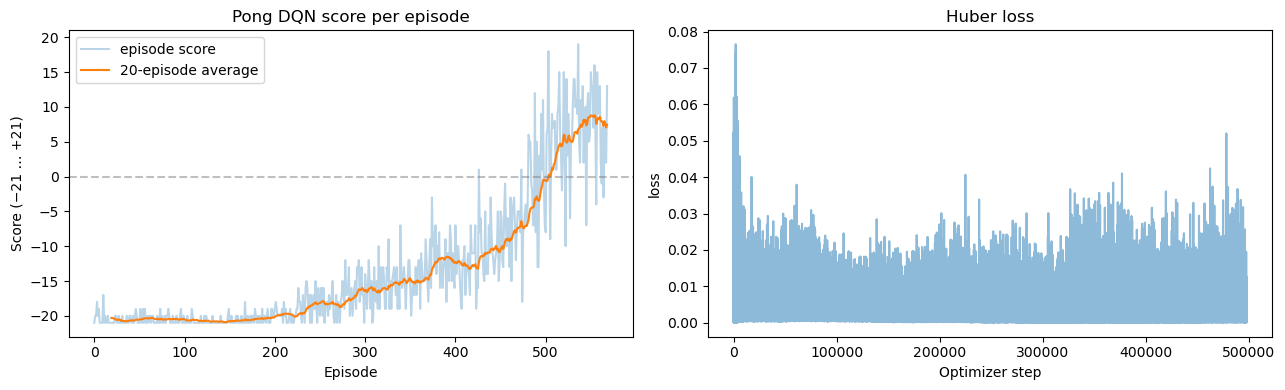

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(episode_rewards, alpha=0.3, label="episode score")
W = 20
if len(episode_rewards) >= W:
    ma = np.convolve(episode_rewards, np.ones(W) / W, mode="valid")
    axes[0].plot(range(W - 1, len(episode_rewards)), ma, label=f"{W}-episode average")
axes[0].axhline(0, ls="--", c="gray", alpha=0.5)
axes[0].set_title("Pong DQN score per episode")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Score (−21 … +21)")
axes[0].legend()

if losses:
    axes[1].plot(losses, alpha=0.5)
    axes[1].set_title("Huber loss")
    axes[1].set_xlabel("Optimizer step"); axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

## Step 11: Evaluate and watch the trained agent

Greedy play (epsilon = 0) over a few episodes, and a recorded video of one game. A well-trained agent should be scoring positively against the built-in opponent.

In [12]:
# --- greedy evaluation ---
def evaluate(policy_net, episodes=5):
    eval_env = make_pong()
    scores = []
    for ep in range(episodes):
        obs, _ = eval_env.reset(seed=10_000 + ep)
        state = np.asarray(obs, dtype=np.uint8)
        total = 0.0
        done = False
        while not done:
            action = select_action(state, epsilon=0.0, policy_net=policy_net, n_actions=eval_env.action_space.n)
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            state = np.asarray(obs, dtype=np.uint8)
            total += reward
            done = terminated or truncated
        scores.append(total)
        print(f"eval episode {ep + 1}: score {total:.0f}")
    eval_env.close()
    print(f"\nmean greedy score over {episodes} episodes: {np.mean(scores):.1f}")
    return scores

_ = evaluate(policy_net, episodes=5)

eval episode 1: score 16
eval episode 2: score 16
eval episode 3: score 9
eval episode 4: score 16
eval episode 5: score 16

mean greedy score over 5 episodes: 14.6


In [13]:
# --- record one episode as a video ---
import imageio, base64
from IPython.display import HTML

rec_env = make_pong(render_mode="rgb_array")
obs, _ = rec_env.reset(seed=123)
state = np.asarray(obs, dtype=np.uint8)
frames, total, done = [], 0.0, False
while not done:
    frames.append(rec_env.render())
    action = select_action(state, epsilon=0.0, policy_net=policy_net, n_actions=rec_env.action_space.n)
    obs, reward, terminated, truncated, _ = rec_env.step(action)
    state = np.asarray(obs, dtype=np.uint8)
    total += reward
    done = terminated or truncated
rec_env.close()
print("recorded game score:", total, "| frames:", len(frames))

import os
os.makedirs("videos", exist_ok=True)
imageio.mimsave("videos/pong.mp4", frames, fps=30)
with open("videos/pong.mp4", "rb") as f:
    enc = base64.b64encode(f.read()).decode("ascii")
HTML(f'<video autoplay loop controls style="height:400px"><source src="data:video/mp4;base64,{enc}" type="video/mp4"></video>')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


recorded game score: 16.0 | frames: 3628


## Notes, expectations, and knobs

**Reading the result**
- Random ≈ **−21**. With this config the curve climbs off −21 by ~**200–300k** frames; **break-even (~0)** around ~1M; strong play (**+15…+21**) by ~2M.
- If after ~500k frames it's still stuck near −21, something in the **Atari setup** is likely off (check the Step 2 smoke test: obs must be `(4,84,84)`, and `n_actions` should print **3**).

**If you hit limits**
- **RAM error / crash:** lower `cfg.replay_capacity` to `50_000`.
- **Too slow / session limit:** lower `cfg.total_frames` (e.g. `1_000_000`) for a first run — it already reaches roughly break-even and shows clear learning.
- **Disconnects:** checkpoint to Google Drive (see Step 8) and use the resume block in Step 9.

**What's included.** This notebook implements the core Nature-DQN recipe **plus Double DQN** (Step 7): reward clipping, 4-frame stacking, a target network, experience replay, and the policy-selects / target-scores update that curbs Q-overestimation. The config (Steps 2–3) is tuned so it actually learns: a **3-action** env and **fast ε-decay** are what get it off the −21 floor.

**The big picture:** same DQN you built for Taxi/CartPole — the *only* fundamental change is **pixels → CNN + frame stacking**. Everything else is scaled-up hyperparameters.